# 🎬 CineSignal — Exploratory Data Analysis

**Question:** _What actually makes a movie successful?_

This notebook is the analytical spine of CineSignal (PRD **FR-0**). It reads the clean
dataset produced by `pipeline/etl.py` and works through the corpus's structure,
missingness, distributions, and relationships — with every claim **supported by a
statistic**, not eyeballed. Its job is to (a) establish what is trustworthy in the data
and (b) **motivate the feature engineering and modeling** in Phase 1 (FR-10).

A running theme: **"success" is three different things** — _revenue_, _profitability_
(ROI), and _reception_ (ratings) — and this notebook keeps them apart, because conflating
them is the classic movie-data mistake.

> **Reproducibility:** run top-to-bottom from a clean environment after
> `python -m pipeline.etl`. Outputs are committed rendered so a reviewer can read without
> executing.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# Consistent, colour-vision-deficiency-safe styling (PRD §13 accessibility).
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

df = pd.read_parquet("../data/processed/movies_clean.parquet")
print(f"Loaded {len(df):,} films × {df.shape[1]} columns")
df.head(3)

Loaded 4,803 films × 26 columns


,id,title,original_title,original_language,budget,revenue,profit,roi,is_profitable,financials_valid,...,runtime,genres,keywords,production_countries,production_companies,director,cast_top,release_date,release_year,release_month
0,5,Four Rooms,Four Rooms,en,4000000,4300000,300000.0,0.075000,True,True,...,98.0,"[Crime, Comedy]","[hotel, new year's eve, witch, bet, hotel room...",[United States of America],"[Miramax Films, A Band Apart]",Allison Anders,"[Tim Roth, Antonio Banderas, Jennifer Beals]",1995-12-09,1995.0,12.0
1,11,Star Wars,Star Wars,en,11000000,775398007,764398007.0,69.490728,True,True,...,121.0,"[Adventure, Action, Science Fiction]","[android, galaxy, hermit, death star, lightsab...",[United States of America],"[Lucasfilm, Twentieth Century Fox Film Corpora...",George Lucas,"[Mark Hamill, Harrison Ford, Carrie Fisher]",1977-05-25,1977.0,5.0
2,12,Finding Nemo,Finding Nemo,en,94000000,940335536,846335536.0,9.003570,True,True,...,100.0,"[Animation, Family]","[father son relationship, harbor, underwater, ...",[United States of America],[Pixar Animation Studios],Andrew Stanton,"[Albert Brooks, Ellen DeGeneres, Alexander Gould]",2003-05-30,2003.0,5.0


## 1. The corpus at a glance (Q1)

Before any analysis, the honest first question is _what is this dataset, and how much of
it can we actually trust for money questions?_

In [2]:
year_min, year_max = int(df.release_year.min()), int(df.release_year.max())
us_share = df.production_countries.apply(
    lambda cs: "United States of America" in cs if isinstance(cs, (list, np.ndarray)) else False
).mean()
en_share = (df.original_language == "en").mean()

summary = pd.Series(
    {
        "Films": f"{len(df):,}",
        "Year span": f"{year_min}–{year_max}",
        "ROI-computable films": f"{int(df.financials_valid.sum()):,} ({df.financials_valid.mean():.0%})",
        "US-produced": f"{us_share:.0%}",
        "English original language": f"{en_share:.0%}",
        "Median audience score": f"{df.vote_average.median():.1f} / 10",
    }
)
summary.to_frame("value")

,value
Films,"4,803"
Year span,1916–2017
ROI-computable films,"3,211 (67%)"
US-produced,82%
English original language,94%
Median audience score,6.2 / 10


**Takeaway.** ~4,800 films spanning a century (1916–2017), but only **~67%** carry usable
financials, and the corpus is heavily **US/English** (82% / 94%). Two consequences we carry
through the whole project: profitability analysis runs on a **subset**, and any finding is
about _mainstream, largely US cinema_ — not "movies" in general. We state this scope limit
rather than imply generality (PRD §7.5, AC-7.1).

## 2. Missingness is not random

33% of films are excluded from ROI because `budget` or `revenue` is 0 (which in TMDB means
_"not reported"_, not _"\$0"_ — decision **D2**). The key question for validity: is that
missingness _random_? If films without financials differ systematically, our profitability
findings are conditional on being a film that reports money.

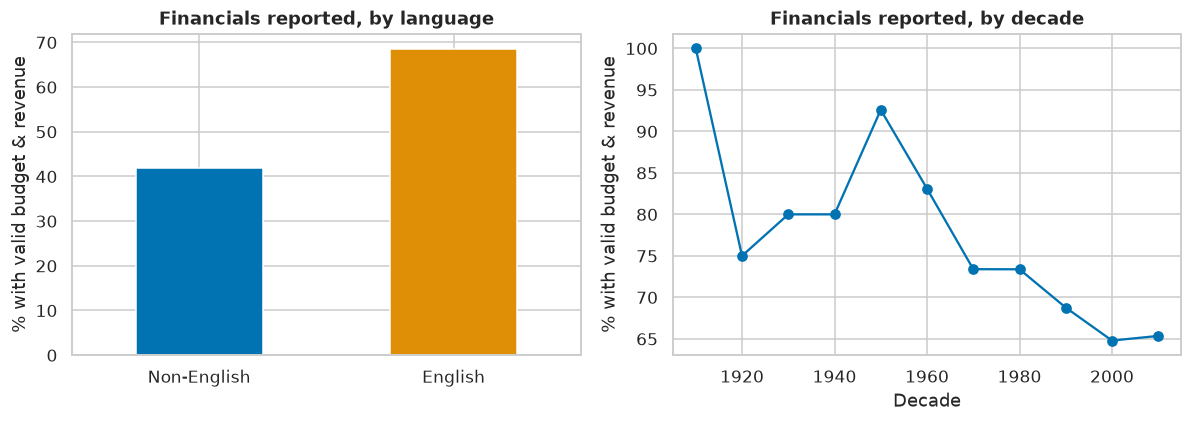

English vs. reports-financials — χ² = 87.8, p = 7.41e-21


In [3]:
df["has_financials"] = df.financials_valid
by_lang = (
    df.assign(is_english=df.original_language.eq("en"))
    .groupby("is_english")
    .has_financials.mean()
    .rename({True: "English", False: "Non-English"})
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
(by_lang * 100).plot.bar(ax=axes[0], color=sns.color_palette("colorblind")[:2])
axes[0].set_title("Financials reported, by language")
axes[0].set_ylabel("% with valid budget & revenue")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

df.assign(decade=(df.release_year // 10 * 10)).groupby("decade").has_financials.mean().mul(
    100
).plot(ax=axes[1], marker="o")
axes[1].set_title("Financials reported, by decade")
axes[1].set_ylabel("% with valid budget & revenue")
axes[1].set_xlabel("Decade")
plt.tight_layout()
plt.show()

# Support the claim with a test of independence.
ct = pd.crosstab(df.original_language.eq("en"), df.has_financials)
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f"English vs. reports-financials — χ² = {chi2:.1f}, p = {p:.2e}")

**Takeaway.** Missingness is **structured**: English-language and more-recent films report
financials far more often. So the ROI sample is **non-randomly missing** (χ², p ≪ 0.001) —
it skews mainstream/recent. Every profitability claim below is implicitly _"among films that
report budget and revenue."_ This is disclosed on the Methodology page (D2), not hidden.

## 3. Distributions — why we report the **median**

The shape of budget, revenue, and ROI dictates which summary statistic is honest.

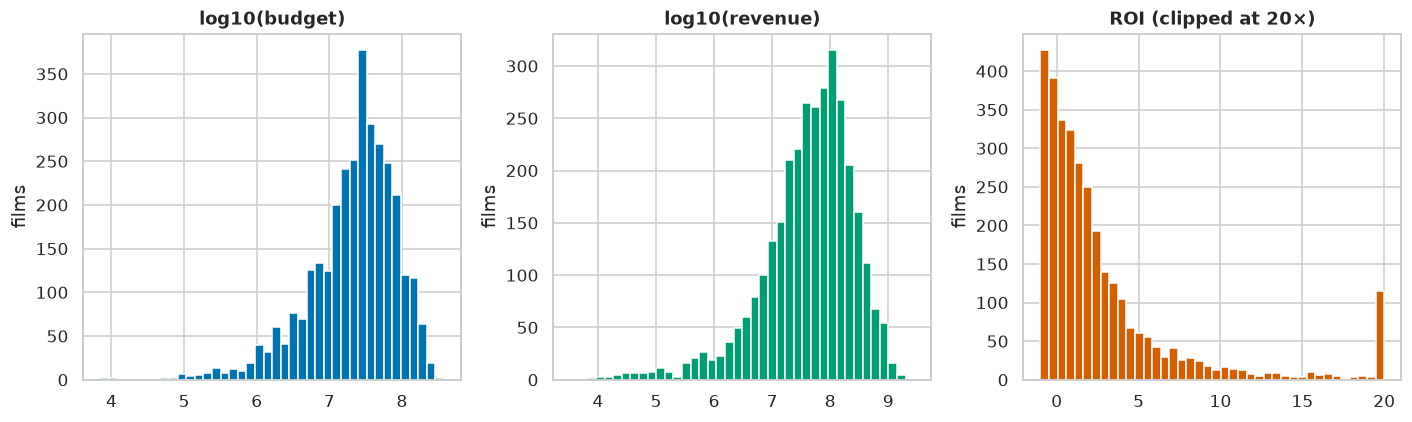

ROI  — median 1.30   mean 10.14   skew 49.7   max 12,889×
% of films profitable (revenue > budget): 75.7%


In [4]:
fin = df[df.financials_valid].copy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(np.log10(fin.budget), bins=40, color=sns.color_palette("colorblind")[0])
axes[0].set_title("log10(budget)")
axes[1].hist(np.log10(fin.revenue), bins=40, color=sns.color_palette("colorblind")[2])
axes[1].set_title("log10(revenue)")
axes[2].hist(fin.roi.clip(upper=20), bins=40, color=sns.color_palette("colorblind")[3])
axes[2].set_title("ROI (clipped at 20×)")
for ax in axes:
    ax.set_ylabel("films")
plt.tight_layout()
plt.show()

print(f"ROI  — median {fin.roi.median():.2f}   mean {fin.roi.mean():.2f}   "
      f"skew {fin.roi.skew():.1f}   max {fin.roi.max():,.0f}×")
print(f"% of films profitable (revenue > budget): {fin.is_profitable.mean():.1%}")

**Takeaway.** Budget and revenue are roughly **log-normal**; ROI is **violently
right-skewed** (skew ≈ 50; one film returns ~13,000×). The **mean ROI (10.1×) is a fiction**
driven by a handful of microbudget breakouts — the **median (1.30×)** is the honest headline.
This directly justifies decision **D4** (median over mean) and the box/violin plots in the
Profitability view. Encouragingly, **~76% of films that report financials are profitable**.

## 4. Budget vs. revenue vs. ROI — bigger budgets earn more, but return **less per dollar** (Q2)

The single most important distinction in the whole product: **grossing high ≠ being
profitable.** Bigger budgets buy bigger revenue — but do they buy a better _return_?

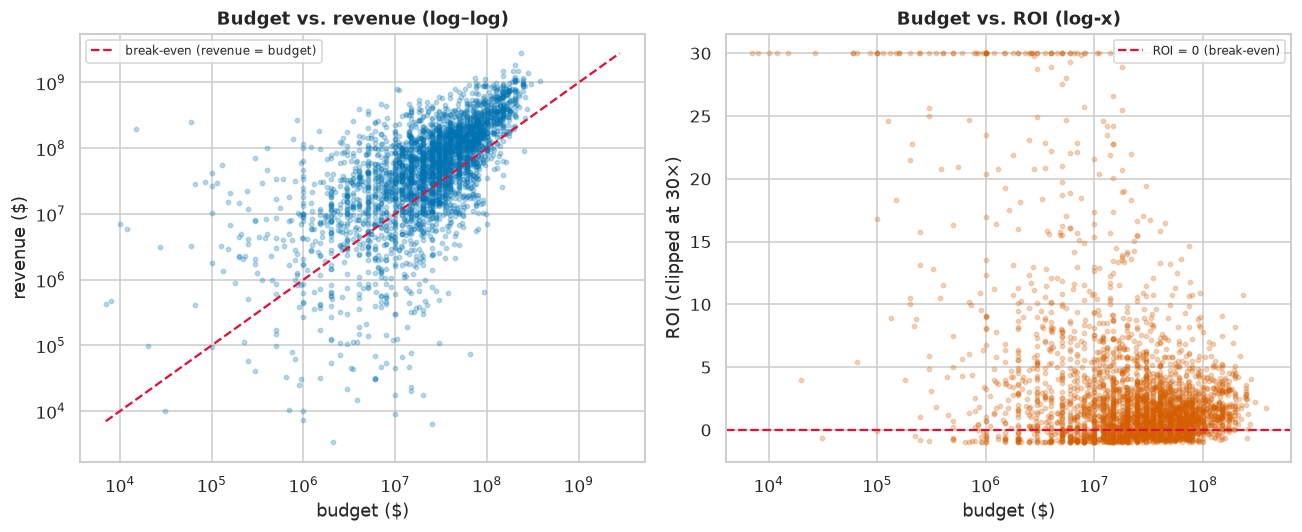

log budget ~ log revenue : Pearson r = 0.62  (p = 0.0e+00)
budget ~ ROI             : Spearman ρ = -0.14  (p = 1.5e-14)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: budget vs revenue, log-log, with break-even line.
axes[0].scatter(fin.budget, fin.revenue, s=8, alpha=0.25,
                color=sns.color_palette("colorblind")[0])
lim = [fin.budget.min(), fin.revenue.max()]
axes[0].plot(lim, lim, "--", color="crimson", lw=1.5, label="break-even (revenue = budget)")
axes[0].set(xscale="log", yscale="log", xlabel="budget ($)", ylabel="revenue ($)",
            title="Budget vs. revenue (log–log)")
axes[0].legend(loc="upper left", fontsize=8)

# Right: budget vs ROI — the relationship that matters for producers.
axes[1].scatter(fin.budget, fin.roi.clip(upper=30), s=8, alpha=0.25,
                color=sns.color_palette("colorblind")[3])
axes[1].axhline(0, color="crimson", ls="--", lw=1.5, label="ROI = 0 (break-even)")
axes[1].set(xscale="log", xlabel="budget ($)", ylabel="ROI (clipped at 30×)",
            title="Budget vs. ROI (log-x)")
axes[1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

r_rev, p_rev = stats.pearsonr(np.log10(fin.budget), np.log10(fin.revenue))
rho_roi, p_roi = stats.spearmanr(fin.budget, fin.roi)
print(f"log budget ~ log revenue : Pearson r = {r_rev:.2f}  (p = {p_rev:.1e})")
print(f"budget ~ ROI             : Spearman ρ = {rho_roi:.2f}  (p = {p_roi:.1e})")

**Takeaway.** Budget and revenue move together strongly (log–log **r = 0.62**) — money buys
gross. But budget and **ROI are _negatively_** related (Spearman **ρ = −0.14**, p ≪ 0.001):
bigger films return **less per dollar**, on average. "Spend more to earn more" is true for
_revenue_ and false for _efficiency_. This is the headline insight the Profitability view is
built to make legible.

## 5. Which genres return the most per dollar? (Q2 / Q3)

Multi-genre films are attributed to **each** of their genres (decision **D6**) — we never sum
a metric across genres (that double-counts), only compare distributions. Genres with < 30
ROI-computable films are dropped to avoid small-sample noise.

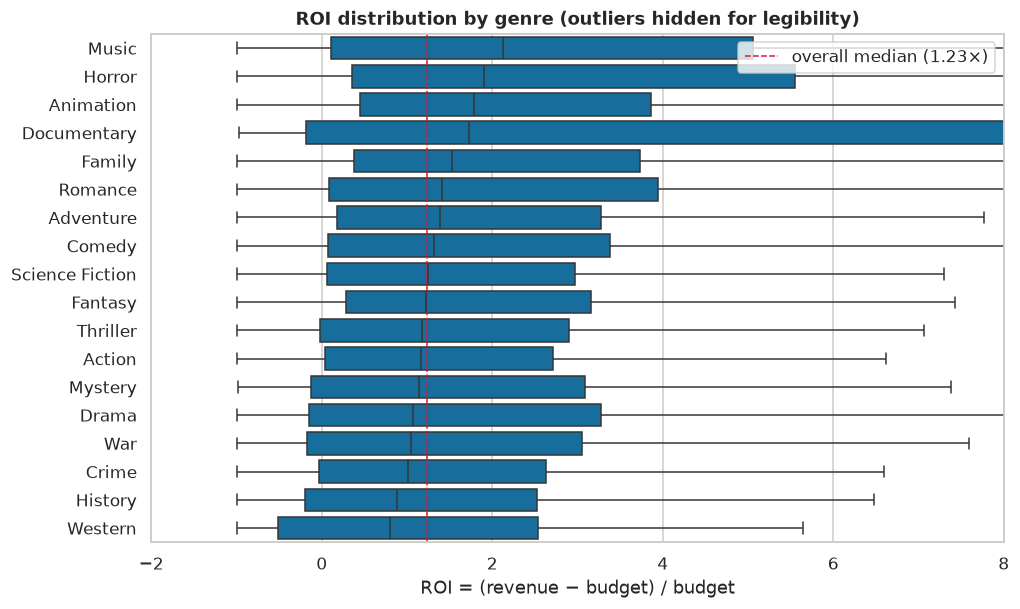

,n,median_roi
genres,,
Music,111,2.12
Horror,329,1.90
Animation,186,1.79
Documentary,37,1.73
Family,364,1.53
Romance,569,1.41
Adventure,660,1.39
Comedy,1101,1.32
Science Fiction,430,1.24



Kruskal–Wallis (ROI differs across genres): H = 82.3, p = 1.5e-10


In [6]:
g = fin.explode("genres")
counts = g.genres.value_counts()
keep = counts[counts >= 30].index
gk = g[g.genres.isin(keep)]
order = gk.groupby("genres").roi.median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=gk, y="genres", x="roi", order=order, showfliers=False,
            color=sns.color_palette("colorblind")[0])
plt.axvline(gk.roi.median(), color="crimson", ls="--", lw=1,
            label=f"overall median ({gk.roi.median():.2f}×)")
plt.xlim(-2, 8)
plt.title("ROI distribution by genre (outliers hidden for legibility)")
plt.xlabel("ROI = (revenue − budget) / budget")
plt.ylabel("")
plt.legend()
plt.show()

med = gk.groupby("genres").roi.agg(n="count", median_roi="median").sort_values(
    "median_roi", ascending=False)
display(med.round(2))

# Do genres differ in ROI beyond chance?
groups = [sub.roi.values for _, sub in gk.groupby("genres")]
H, p = stats.kruskal(*groups)
print(f"\nKruskal–Wallis (ROI differs across genres): H = {H:.1f}, p = {p:.1e}")

**Takeaway.** Genre matters, and the difference is **not chance** (Kruskal–Wallis, p ≪
0.001). **Horror, Music, and Animation** top the table on median ROI while **Western,
History, and Crime** sit at the bottom — and notably, the low-budget genres (horror
especially) beat the expensive ones on _return_, echoing §4. This is a concrete, defensible
answer to _"what is profitable?"_ that a producer (persona Dana) can act on.

## 6. The budget-tier "smile" — microbudget and tentpole extremes

Binning budget into documented tiers (micro → tentpole) exposes a non-monotone pattern.

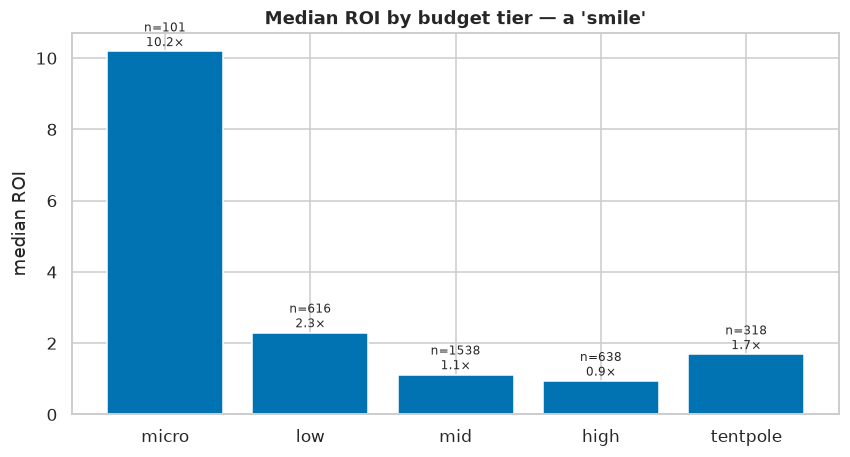

,n,median_roi,median_revenue
budget_tier,,,
micro,101,10.19,"$3,542,353"
low,616,2.30,"$12,616,874"
mid,1538,1.12,"$48,439,933"
high,638,0.94,"$128,438,494"
tentpole,318,1.68,"$370,555,515"


In [7]:
tier_order = ["micro", "low", "mid", "high", "tentpole"]
tstats = (
    fin.groupby("budget_tier", observed=True)
    .agg(n=("roi", "count"), median_roi=("roi", "median"), median_revenue=("revenue", "median"))
    .reindex(tier_order)
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(tstats.index, tstats.median_roi, color=sns.color_palette("colorblind")[0])
ax.set_title("Median ROI by budget tier — a 'smile'")
ax.set_ylabel("median ROI")
for i, (n, r) in enumerate(zip(tstats.n, tstats.median_roi)):
    ax.text(i, r + 0.15, f"n={n}\n{r:.1f}×", ha="center", fontsize=8)
plt.show()
display(tstats.assign(median_revenue=tstats.median_revenue.map("${:,.0f}".format)).round(2))

**Takeaway.** ROI is **not monotone** in budget — it forms a rough "smile": **micro-budget**
films post the highest median ROI (10×, but on just ~100 films and a brutal heavy tail — high
risk, survivorship-flavoured), the middle tiers are efficient-but-modest, and **tentpoles
rebound** (1.7×) because studios greenlight them precisely when confident. The takeaway for
modeling: **budget's effect on ROI is non-linear**, so a tree-based model (or an explicit
tier feature) will beat a plain linear term — a Phase-1 design cue.

## 7. Does reception relate to money?

Audience score is the one reception axis TMDB gives us (no critic score — see D1). Does being
_liked_ track with _earning_?

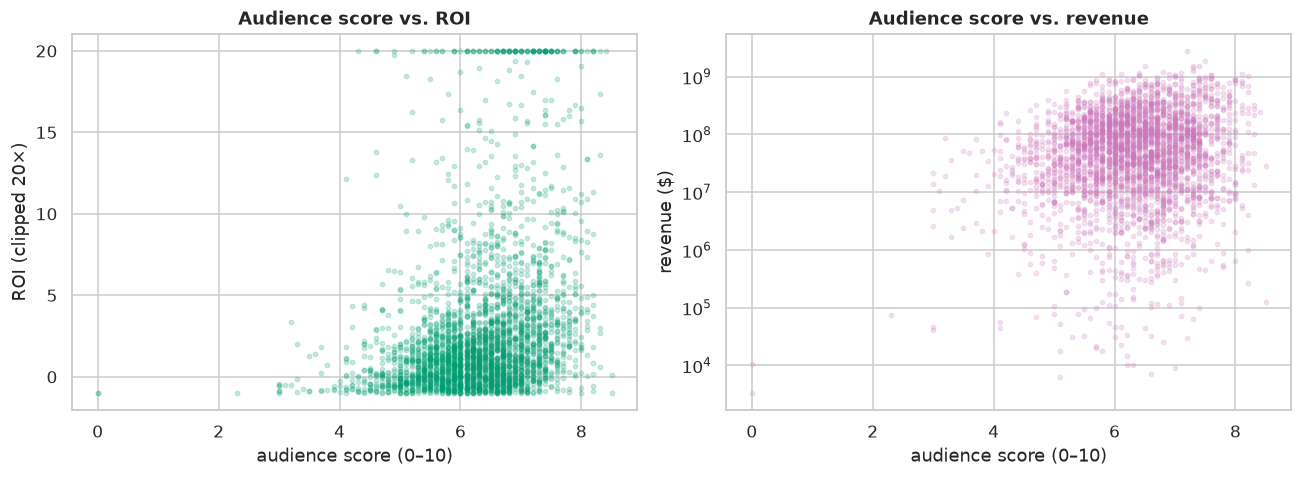

audience score ~ ROI     : Spearman ρ = 0.34  (p = 7.6e-86)
audience score ~ revenue : Spearman ρ = 0.13  (p = 4.4e-13)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(fin.vote_average, fin.roi.clip(upper=20), s=8, alpha=0.2,
                color=sns.color_palette("colorblind")[2])
axes[0].set(xlabel="audience score (0–10)", ylabel="ROI (clipped 20×)",
            title="Audience score vs. ROI")
axes[1].scatter(fin.vote_average, fin.revenue, s=8, alpha=0.2,
                color=sns.color_palette("colorblind")[4])
axes[1].set(xlabel="audience score (0–10)", ylabel="revenue ($)", yscale="log",
            title="Audience score vs. revenue")
plt.tight_layout()
plt.show()

for name, col in [("ROI", fin.roi), ("revenue", fin.revenue)]:
    rho, p = stats.spearmanr(fin.vote_average, col)
    print(f"audience score ~ {name:8s}: Spearman ρ = {rho:.2f}  (p = {p:.1e})")

**Takeaway.** Being liked relates **moderately to ROI (ρ = 0.34)** but only **weakly to
revenue (ρ = 0.13)** — quality helps _efficiency_ more than it helps gross. Crucially,
`vote_average` and `vote_count` are **post-release** signals: they exist only _after_ a film
opens, so they **must not** be used to _predict_ a pre-release target (leakage; AC-10.2).
They belong in the descriptive Critics/Reception views, **not** in the model's feature set.

## 8. Seasonality — when a film opens

Release month is a fully **pre-release**, leakage-safe signal — the kind of feature the model
_can_ use.

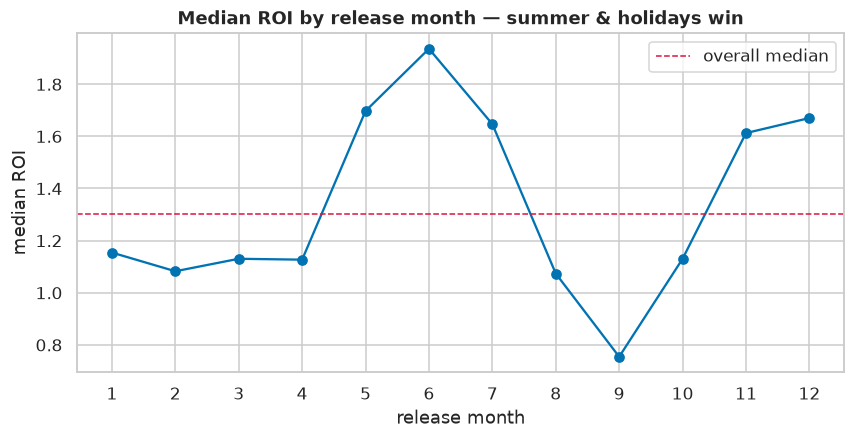

release_month
1.0     1.15
2.0     1.08
3.0     1.13
4.0     1.13
5.0     1.70
6.0     1.94
7.0     1.65
8.0     1.07
9.0     0.75
10.0    1.13
11.0    1.61
12.0    1.67


In [9]:
month_roi = fin.groupby("release_month").roi.median()
plt.figure(figsize=(9, 4))
plt.plot(month_roi.index, month_roi.values, marker="o", color=sns.color_palette("colorblind")[0])
plt.axhline(fin.roi.median(), color="crimson", ls="--", lw=1, label="overall median")
plt.xticks(range(1, 13))
plt.title("Median ROI by release month — summer & holidays win")
plt.xlabel("release month")
plt.ylabel("median ROI")
plt.legend()
plt.show()
print(month_roi.round(2).to_string())

**Takeaway.** A clear **seasonal signal**: **May–July** (summer blockbuster season) and
**November–December** (holidays) show the strongest median ROI, while **September** is the
weakest — the industry's "dump month" reputation shows up in the data. Because month is known
_before_ release, **release-season is a legitimate model feature** (AC-10.5), and it's
motivated here rather than added blindly.

## 9. Synthesis → what this means for the model (bridge to FR-10)

The EDA hands the modeling phase a concrete, evidence-backed brief:

| Finding (this notebook) | Modeling implication (Phase 1) |
|---|---|
| ROI is violently right-skewed (§3) | Model **log-revenue** or a **profitability class**, not raw ROI; report **median-based** baselines |
| Budget ↔ ROI is negative & **non-linear** "smile" (§4, §6) | Prefer **tree-based** models / include an explicit **budget-tier** feature over a bare linear term |
| Genre materially shifts ROI (§5) | **Genre encodings** are high-value features; multi-genre → multi-hot |
| Season matters and is pre-release (§8) | **Release-month/season** is a safe, motivated feature |
| `vote_*`, `popularity` are **post-release** (§7) | **Exclude** from any pre-release predictor — leakage (AC-10.2) |
| Missingness is non-random (§2) | Scope claims to "films that report financials"; consider it a **selection caveat** |

**Baseline to beat (AC-10.3):** predicting the **median** outcome for every film. A useful
model must beat that, and the point of the exercise is the **interpretation** — _which of
these drivers matters most_ — not the score itself.

**Target framing (AC-10.1):** a leakage-free, pre-release setting predicting **profitability**
(revenue relative to budget), with a **temporal split** (train on older films, test on newer)
so we never use the future to predict the past.

> Next: Phase 1 turns this brief into engineered features and an honest, interpretable model.